# SurpriseAI — Earnings Surprise Transformer (Colab)

**How to use:**
1. Runtime → Change runtime type → **GPU (T4 is fine)**.
2. Run the **Setup** cell. It will prompt you to upload either:
   - a single `.zip` containing all your `{TICKER}_ERN.csv` and `{TICKER}_DETAIL.csv` files, **or**
   - individual CSV files (select multiple).
3. Run the rest of the cells in order.

The pipeline expects file pairs `{TICKER}_ERN.csv` (earnings history, Bloomberg-style with header row + "Average of Absolute Values" row) and `{TICKER}_DETAIL.csv` (per-analyst estimates).



Note: results may look slightly different from paper due to a last run before submission

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#1. Introduction to libraries
 Used basic deep learning packages such as pytorch, numpy, pandas, sklearn in order to preprocess our data and build the model
We also used them for evaluation towards the end of the notebook

In [ ]:
# === Setup: install + imports ===
!pip install -q torch scikit-learn pandas numpy
import math, os, glob, re, io, zipfile, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from typing import Optional
print("imports OK | torch", torch.__version__, "| CUDA:", torch.cuda.is_available())


imports OK | torch 2.11.0+cu128 | CUDA: True


In [ ]:
# === Load data from Google Drive ===
from google.colab import drive
import os, glob, shutil

drive.mount('/content/drive')

# CHANGE THIS to your Drive folder that contains the ERN/ and DETAIL/ subfolders
DRIVE_FOLDER = "/content/drive/MyDrive/SurprisePredictionModel"

DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

# Flatten: copy every CSV (from any subfolder) into /content/data
for p in glob.glob(os.path.join(DRIVE_FOLDER, "**", "*.csv"), recursive=True):
    shutil.copy(p, DATA_DIR)

csvs = sorted(os.listdir(DATA_DIR))
ern_files    = [f for f in csvs if f.endswith("_ERN.csv")]
detail_files = [f for f in csvs if f.endswith("_DETAIL.csv")]
print(f"Copied into {DATA_DIR}: {len(ern_files)} ERN, {len(detail_files)} DETAIL")

ern_tickers    = {f.replace("_ERN.csv","")    for f in ern_files}
detail_tickers = {f.replace("_DETAIL.csv","") for f in detail_files}
missing_detail = ern_tickers - detail_tickers
missing_ern    = detail_tickers - ern_tickers
if missing_detail: print("  WARN: ERN without DETAIL:", sorted(missing_detail)[:10])
if missing_ern:    print("  WARN: DETAIL without ERN:", sorted(missing_ern)[:10])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied into /content/data: 98 ERN, 95 DETAIL
  WARN: ERN without DETAIL: ['BRK.B', 'CAT', 'GOOG', 'GOOGL', 'PG', 'PLTR']
  WARN: DETAIL without ERN: ['ADBE', 'SO', 'TMO']


#Takes the data uploaded from local machine (from Bloomberg terminal) and preprocesses it to be used in the model

In [ ]:
import math, os, glob, re, io, zipfile, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from typing import Optional
# === Data Loading ===
def parse_pct(s):
    s = str(s).replace("%","").strip()
    if s in ("", "N.M.", "NM", "nan", "NaN", "—", "-", "#N/A"):
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

def normalize_period(s):
    """Normalize period strings between ERN ('Q1 25') and DETAIL ('2025 Q1')."""
    s = str(s).strip()
    m = re.match(r"Q(\d) (\d{2})$", s)
    if m:
        return f"{2000 + int(m.group(2))} Q{m.group(1)}"
    return s

def load_stock(ticker, data_dir):
    # Skip the "Average of Absolute Values" row that Bloomberg exports
    ern = pd.read_csv(os.path.join(data_dir, f"{ticker}_ERN.csv"))
    ern.columns = ern.columns.str.strip().str.lower() # Convert column names to lowercase
    ern = ern[ern["ann date"].notna() & (ern["ann date"].astype(str).str.strip() != "")]
    ern = ern[ern["reported"].notna() & (ern["reported"].astype(str).str.strip() != "")]
    ern = ern.rename(columns={
        "ann date": "ann_date", "per": "period_raw", "reported": "reported",
        "estimate": "consensus", "%surp": "pct_surp", "%px chg": "pct_px_chg",
        "t12m": "t12m", "p/e": "pe",
    })
    for c in ["reported","consensus","pct_surp","pct_px_chg","t12m","pe"]:
        if c not in ern.columns:
            ern[c] = np.nan
    ern["period"]     = ern["period_raw"].apply(normalize_period)
    ern["reported"]   = pd.to_numeric(ern["reported"],  errors="coerce")
    ern["consensus"]  = pd.to_numeric(ern["consensus"], errors="coerce")
    ern["pct_surp"]   = ern["pct_surp"].apply(parse_pct)
    ern["pct_px_chg"] = ern["pct_px_chg"].apply(parse_pct)
    ern["t12m"]       = pd.to_numeric(ern["t12m"], errors="coerce")
    ern["pe"]         = pd.to_numeric(ern["pe"],   errors="coerce")
    ern["ann_date"]   = pd.to_datetime(ern["ann_date"])
    ern["ticker"]     = ticker

    det = pd.read_csv(os.path.join(data_dir, f"{ticker}_DETAIL.csv"))
    det = det.rename(columns={
        "#est().period":               "period_raw",
        "#est().firm_name":            "firm_name",
        "#est().ANALYST_NAME":         "analyst_name",
        "#est().value":                "estimate_value",
        "#est().est_source_specified": "firm_code",
    })
    det["period"] = det["period_raw"].apply(normalize_period)
    det["ticker"] = ticker

    merged = ern[["ticker","period","ann_date","reported","consensus",
                  "pct_surp","pct_px_chg","t12m","pe"]].merge(
        det[["ticker","period","firm_name","analyst_name","firm_code","estimate_value"]],
        on=["ticker","period"], how="inner",
    )
    return merged

def load_all_stocks(data_dir, tickers=None):
    if tickers is None:
        tickers = sorted({os.path.basename(f).replace("_ERN.csv","")
                          for f in glob.glob(os.path.join(data_dir, "*_ERN.csv"))})
    dfs = []
    for t in tickers:
        try:
            dfs.append(load_stock(t, data_dir))
        except Exception as e:
            print(f"  skip {t}: {e}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

df_all = load_all_stocks(DATA_DIR)
print(f"Loaded {df_all['ticker'].nunique()} stocks | "
      f"{df_all[['ticker','period']].drop_duplicates().shape[0]} quarter-announcements | "
      f"{len(df_all):,} analyst-estimate rows")
df_all.head()


  skip BRK.B: [Errno 2] No such file or directory: '/content/data/BRK.B_DETAIL.csv'
  skip CAT: [Errno 2] No such file or directory: '/content/data/CAT_DETAIL.csv'
  skip GOOG: [Errno 2] No such file or directory: '/content/data/GOOG_DETAIL.csv'
  skip GOOGL: [Errno 2] No such file or directory: '/content/data/GOOGL_DETAIL.csv'
  skip PG: [Errno 2] No such file or directory: '/content/data/PG_DETAIL.csv'
  skip PLTR: [Errno 2] No such file or directory: '/content/data/PLTR_DETAIL.csv'
Loaded 92 stocks | 1766 quarter-announcements | 6,936 analyst-estimate rows


,ticker,period,ann_date,reported,consensus,pct_surp,pct_px_chg,t12m,pe,firm_name,analyst_name,firm_code,estimate_value
0,AAPL,2025 Q4,2025-10-30,1.85,1.774,4.28,-0.38,7.47,34.09,"Eugene Investment & Securities Co., Ltd.",Seungwoo Lee,EUG,1.56
1,AAPL,2025 Q4,2025-10-30,1.85,1.774,4.28,-0.38,7.47,34.09,D.A. Davidson,Gil B Luria,DAD,1.80
2,AAPL,2025 Q4,2025-10-30,1.85,1.774,4.28,-0.38,7.47,34.09,Wedbush,"Daniel Ives ""Dan""",WMS,1.76
3,AAPL,2025 Q4,2025-10-30,1.85,1.774,4.28,-0.38,7.47,34.09,Yuanta,Lisa Chen,YUT,1.66
4,AAPL,2025 Q4,2025-10-30,1.85,1.774,4.28,-0.38,7.47,34.09,KGI Securities Co Ltd,Rob Chang,KGI,1.82


#More preprocessing via feature engineering:
Generates normalized estimate features, adds lagged quarterly earnings,
clips extreme outliers, and performs a strict chronological train/val/test split to prevent look-ahead bias.

In [ ]:
# === Feature Engineering ===

def engineer_features(df):
    qstats = df.groupby(["ticker","period"])["estimate_value"].agg(
        q_mean="mean", q_std="std"
    ).reset_index()
    df = df.merge(qstats, on=["ticker","period"], how="left")
    df["q_std"] = df["q_std"].fillna(0.0)
    df["diff_from_mean"] = df["estimate_value"] - df["q_mean"]
    df["norm_estimate"]  = df["diff_from_mean"] / (df["q_std"] + 1e-8)

    qmap = (df[["ticker","period","ann_date","reported"]]
            .drop_duplicates(["ticker","period"])
            .sort_values(["ticker","ann_date"]))
    qmap["prior_reported"] = qmap.groupby("ticker")["reported"].shift(1)
    df = df.merge(qmap[["ticker","period","prior_reported"]], on=["ticker","period"], how="left")
    df["prior_reported"] = df["prior_reported"].fillna(df["reported"].median())

    # Clip extreme surprises (e.g. COVID Q1 2020) so they don't dominate the loss
    df["pct_surp"]   = df["pct_surp"].clip(-50, 50)
    df["pct_px_chg"] = df["pct_px_chg"].clip(-30, 30)
    return df

def build_analyst_vocab(train_df):
    """Vocab from train only; 0 = padding/UNK."""
    return {name: i+1 for i, name in enumerate(train_df["analyst_name"].unique())}

def chronological_split(df, val_frac=0.15, test_frac=0.15):
    dates = (df[["ticker","period","ann_date"]]
             .drop_duplicates(["ticker","period"])
             .sort_values("ann_date"))
    n = len(dates)
    val_start  = dates.iloc[int(n * (1 - val_frac - test_frac))]["ann_date"]
    test_start = dates.iloc[int(n * (1 - test_frac))]["ann_date"]
    return (df[df["ann_date"] <  val_start],
            df[(df["ann_date"] >= val_start) & (df["ann_date"] < test_start)],
            df[df["ann_date"] >= test_start])

df_all = engineer_features(df_all)
train_df, val_df, test_df = chronological_split(df_all)
print(f"train: {train_df[['ticker','period']].drop_duplicates().shape[0]} | "
      f"val: {val_df[['ticker','period']].drop_duplicates().shape[0]} | "
      f"test: {test_df[['ticker','period']].drop_duplicates().shape[0]} announcements")


train: 1236 | val: 261 | test: 269 announcements


#Dataset
One sample = one (ticker, quarter) earnings announcement.
    Sequence tokens = analyst estimates for that quarter, padded to max_analysts.

In [ ]:
# === Dataset ===
CONT_COLS = ["estimate_value", "diff_from_mean", "norm_estimate", "prior_reported"]

class EarningsDataset(Dataset):
    def __init__(self, df, analyst_vocab, scaler=None, max_analysts=50, fit_scaler=False):
        self.max_analysts = max_analysts
        self.analyst_vocab = analyst_vocab

        cont_data = df[CONT_COLS].values.astype(np.float32)
        if fit_scaler:
            self.scaler = StandardScaler()
            cont_data = self.scaler.fit_transform(cont_data)
        elif scaler is not None:
            self.scaler = scaler
            cont_data = self.scaler.transform(cont_data)
        else:
            self.scaler = None
        df = df.copy()
        df[CONT_COLS] = cont_data

        self.samples = []
        for (ticker, period), grp in df.groupby(["ticker","period"]):
            surp = grp["pct_surp"].iloc[0]
            ret  = grp["pct_px_chg"].iloc[0]
            if pd.isna(surp):
                continue
            self.samples.append({
                "cont":      grp[CONT_COLS].values.astype(np.float32),
                "aids":      np.array([analyst_vocab.get(a, 0) for a in grp["analyst_name"]], dtype=np.int64),
                "surprise":  np.float32(surp),
                "ret":       np.float32(0.0 if pd.isna(ret) else ret),
                "ret_valid": not pd.isna(ret),
            })

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        T = min(len(s["cont"]), self.max_analysts)
        cont = np.zeros((self.max_analysts, len(CONT_COLS)), dtype=np.float32)
        aids = np.zeros(self.max_analysts, dtype=np.int64)
        mask = np.ones(self.max_analysts, dtype=bool)
        cont[:T] = s["cont"][:T]
        aids[:T] = s["aids"][:T]
        mask[:T] = False
        return {
            "cont_features": torch.tensor(cont),
            "analyst_ids":   torch.tensor(aids),
            "pad_mask":      torch.tensor(mask),
            "surprise":      torch.tensor(s["surprise"]),
            "ret":           torch.tensor(s["ret"]),
            "ret_valid":     torch.tensor(s["ret_valid"]),
        }

analyst_vocab = build_analyst_vocab(train_df)
n_analysts = len(analyst_vocab) + 1
print(f"analyst vocab size: {n_analysts} (incl. padding/UNK)")

train_ds = EarningsDataset(train_df, analyst_vocab, fit_scaler=True,  max_analysts=50)
val_ds   = EarningsDataset(val_df,   analyst_vocab, scaler=train_ds.scaler, max_analysts=50)
test_ds  = EarningsDataset(test_df,  analyst_vocab, scaler=train_ds.scaler, max_analysts=50)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64)
test_loader  = DataLoader(test_ds,  batch_size=64)
print(f"train/val/test samples: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")


analyst vocab size: 249 (incl. padding/UNK)
train/val/test samples: 1219 / 261 / 267


#2. Model Design & Implementation: Transformer
The transformer has 76,690 parameters: a 16-dimensional analyst embedding table, a linear projection from the
20-dimensional combined input (four continuous features plus the 16-dimensional embedding) to a 64-dimensional
model space, two encoder layers with four attention heads and a 128-dimensional feedforward block, and two small
prediction heads.

# INPUTS:
cont_features: [Batch, Seq, 4] = Actual data of earnings over time

analyst_ids:   [Batch, Seq]    = Embedding of analyst and the time that they made a prediction

pad_mask:      [Batch, Seq]    = True when padding is present, is False if there is none

# OUTPUTS:
returns a tuple: (surprise_tensor, return_tensor)

Both outputs are 1D vectors of shape [Batch] containing continuous predictions.

In [ ]:
# === Model ===
#Defining the model
class EarningsTransformer(nn.Module):
    def __init__(self, n_analysts, d_emb=16, d_cont=4, d_model=64, n_heads=4,
                 n_layers=2, d_ff=128, max_len=51, dropout=0.1, use_analyst_emb=True):
        super().__init__()
        self.use_analyst_emb = use_analyst_emb
        self.d_model = d_model
        #Since we want to test with and without embeddings we check to instantiate
        if use_analyst_emb:
            self.analyst_emb = nn.Embedding(n_analysts, d_emb, padding_idx=0)
            d_input = d_cont + d_emb
        else:
            self.analyst_emb = None
            d_input = d_cont
        #Ensures each layer is the same size
        self.input_proj = nn.Sequential(nn.Linear(d_input, d_model), nn.LayerNorm(d_model))
        #Most important part: aggregates to the start of the input sequence for semantic and contextual information
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model))

        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                                               dim_feedforward=d_ff, dropout=dropout,
                                               batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        #Two heads, one for the learned surprise and for the learned return
        self.surprise_head = nn.Sequential(nn.Linear(d_model, d_model // 2),
                                           nn.ReLU(),
                                           nn.Linear(d_model // 2, 1))
        self.return_head   = nn.Sequential(nn.Linear(d_model, d_model // 2),
                                           nn.ReLU(),
                                           nn.Linear(d_model // 2, 1))

#A pass of the network, maniputlating tensors
    def forward(self, cont_features, analyst_ids, pad_mask):
        B = cont_features.size(0)
        if self.use_analyst_emb:
            x = torch.cat([cont_features, self.analyst_emb(analyst_ids)], dim=-1)
        else:
            x = cont_features
        x = self.input_proj(x)
        cls = self.cls_token.expand(B, 1, self.d_model)
        x = torch.cat([cls, x], dim=1)
        cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=pad_mask.device)
        #Masking since the input will be changed from CLS token
        pad_mask_ext = torch.cat([cls_mask, pad_mask], dim=1)
        encoded = self.encoder(x, src_key_padding_mask=pad_mask_ext)
        cls_out = encoded[:, 0, :]
        return self.surprise_head(cls_out).squeeze(-1), self.return_head(cls_out).squeeze(-1)

#Defining the Training Loop
Where all the training tools and logic are defined such as train_epoch, evaluate, and train

In [ ]:
# === Training Loop ===

#Loader is the type of data, which can be a train_loader (training dataset), val_loader (validation dataset), or test_loader (testing dataset)
# Defined as one epoch in the model,
def train_epoch(model, loader, optimizer, device, lambda_return=0.5):
    model.train()
    total_loss, huber = 0.0, nn.SmoothL1Loss(beta=5.0)   # Huber is the loss funciton used, mse across the notebook refers to the evaluation metric
    for batch in loader:
        cont    = batch["cont_features"].to(device)
        aids    = batch["analyst_ids"].to(device)
        mask    = batch["pad_mask"].to(device)
        surp    = batch["surprise"].to(device)
        ret     = batch["ret"].to(device)
        ret_ok  = batch["ret_valid"].to(device)
        optimizer.zero_grad()
        surp_pred, ret_pred = model(cont, aids, mask)
        loss = huber(surp_pred, surp)
        if ret_ok.any() and lambda_return > 0:
            loss = loss + lambda_return * huber(ret_pred[ret_ok], ret[ret_ok])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
#Simple evaluation function that takes the predicted and target value and compares them
def evaluate(model, loader, device):
    model.eval()
    preds_all, targets_all = [], []
    for batch in loader:
        cont = batch["cont_features"].to(device)
        aids = batch["analyst_ids"].to(device)
        mask = batch["pad_mask"].to(device)
        surp = batch["surprise"].numpy()
        surp_pred, _ = model(cont, aids, mask)
        preds_all.append(surp_pred.cpu().numpy())
        targets_all.append(surp)
    preds   = np.concatenate(preds_all)
    targets = np.concatenate(targets_all)
    return {
        "mse":     float(np.mean((preds - targets) ** 2)),
        "mae":     float(np.mean(np.abs(preds - targets))),
        "dir_acc": float(np.mean(np.sign(preds) == np.sign(targets))),
    }

#Core training loop, instantiates the model and all necessary steps for training on every Epoch
def train(model, train_loader, val_loader, n_epochs=50, lr=1e-4, weight_decay=1e-2,
          lambda_return=0.5, patience=10, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = n_epochs * len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.05)
    best_val_mse, best_state, no_improve = float("inf"), None, 0
    for epoch in range(1, n_epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, device, lambda_return)
        scheduler.step()
        m = evaluate(model, val_loader, device)
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | "
              f"val_mse={m['mse']:.4f} | val_mae={m['mae']:.4f} | val_dir_acc={m['dir_acc']:.4f}")
        if m["mse"] < best_val_mse:
            best_val_mse, best_state, no_improve = m["mse"], {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break
    model.load_state_dict(best_state)
    return model

#3. Training Process
Using the data to train the model and evaluate it. Where all the tools and logic come together to obtain results on consensus data.

In [ ]:
# === Train & Evaluate ===

#Instantiaing the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = EarningsTransformer(
    n_analysts=n_analysts,
    d_emb=16, d_cont=len(CONT_COLS), d_model=64, n_heads=4,
    n_layers=2, d_ff=128, max_len=51, dropout=0.1,
)
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

#Training with the train and the val dataset
trained_model = train(model, train_loader, val_loader, n_epochs=50, lr=1e-4, device=device)
#Evaluating with the test dataset
test_metrics = evaluate(trained_model, test_loader, device)
print("\nTEST metrics:", test_metrics)


Device: cuda
Model params: 76,690


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 001 | train_loss=10.3822 | val_mse=263.6919 | val_mae=10.5945 | val_dir_acc=0.1303
Epoch 002 | train_loss=10.6177 | val_mse=263.1275 | val_mae=10.5653 | val_dir_acc=0.1303
Epoch 003 | train_loss=10.5493 | val_mse=262.5396 | val_mae=10.5349 | val_dir_acc=0.1341
Epoch 004 | train_loss=10.3973 | val_mse=261.9332 | val_mae=10.5032 | val_dir_acc=0.2605
Epoch 005 | train_loss=10.2762 | val_mse=261.2929 | val_mae=10.4697 | val_dir_acc=0.4483
Epoch 006 | train_loss=10.7984 | val_mse=260.6104 | val_mae=10.4337 | val_dir_acc=0.6245
Epoch 007 | train_loss=10.0933 | val_mse=259.8868 | val_mae=10.3956 | val_dir_acc=0.8314
Epoch 008 | train_loss=10.2101 | val_mse=259.0849 | val_mae=10.3542 | val_dir_acc=0.8697
Epoch 009 | train_loss=10.4432 | val_mse=258.2192 | val_mae=10.3097 | val_dir_acc=0.8697
Epoch 010 | train_loss=10.5766 | val_mse=257.3109 | val_mae=10.2622 | val_dir_acc=0.8697
Epoch 011 | train_loss=10.4243 | val_mse=256.3547 | val_mae=10.2119 | val_dir_acc=0.8697
Epoch 012 | train_los

#LSTM Component

Isolates whether attention helps to identify any valuable analysts, or analysts that should be more paid attention to

Evaluation is done right away, so metrics are at the bottom

Inputs: same as transformer model

Outputs: Head outputs flattens to [B] via .squeeze(-1) for easy loss tracking.


In [ ]:
# Same forward(cont_features, analyst_ids, pad_mask) signature and two heads as
# EarningsTransformer, so it reuses train()/evaluate()/collect() unchanged.
class EarningsLSTM(nn.Module):
    def __init__(self, n_analysts, d_emb=16, d_cont=4, d_model=64, hidden=64,
                 n_layers=2, dropout=0.1, bidirectional=True, use_analyst_emb=True):
        super().__init__()
        self.use_analyst_emb = use_analyst_emb
        if use_analyst_emb:
            self.analyst_emb = nn.Embedding(n_analysts, d_emb, padding_idx=0)
            d_input = d_cont + d_emb
        else:
            self.analyst_emb = None
            d_input = d_cont
        self.input_proj = nn.Sequential(nn.Linear(d_input, d_model), nn.LayerNorm(d_model))
        #Key difference from transformer, no CLS, just takes in one sequence at a time
        self.lstm = nn.LSTM(d_model, hidden, num_layers=n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0,
                            bidirectional=bidirectional)
        d_out = hidden * (2 if bidirectional else 1)
        #Still need two heads, one for surprise and return
        self.surprise_head = nn.Sequential(nn.Linear(d_out, d_out // 2), nn.ReLU(),
                                           nn.Linear(d_out // 2, 1))
        self.return_head   = nn.Sequential(nn.Linear(d_out, d_out // 2), nn.ReLU(),
                                           nn.Linear(d_out // 2, 1))

    def forward(self, cont_features, analyst_ids, pad_mask):
        # pad_mask: True = padding, False = real token (matches EarningsDataset)
        if self.use_analyst_emb:
            x = torch.cat([cont_features, self.analyst_emb(analyst_ids)], dim=-1)
        else:
            x = cont_features
        x = self.input_proj(x)
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).cpu()   # clamp guards all-padding rows
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        #h_n[-1] is the forward pass final state.
        #h_n[-2] is the backward pass final state.
        if self.lstm.bidirectional:
            summary = torch.cat([h_n[-2], h_n[-1]], dim=-1)   # last layer, both directions
        else:
            summary = h_n[-1]
        return self.surprise_head(summary).squeeze(-1), self.return_head(summary).squeeze(-1)


#Smoke tests: shapes, both ablation settings, gradients, all-padding edge case are all tested in this function
def _smoke_test_lstm():
    B, T = 8, 50
    cont = torch.randn(B, T, len(CONT_COLS))
    aids = torch.randint(0, n_analysts, (B, T))
    mask = torch.ones(B, T, dtype=torch.bool)
    for b in range(B):                       # variable real lengths + padding
        L = np.random.randint(1, T + 1)
        mask[b, :L] = False
        aids[b, L:] = 0
    surp, ret = torch.randn(B), torch.randn(B)
    huber = nn.SmoothL1Loss(beta=5.0)

    for use_emb in (True, False):
        m = EarningsLSTM(n_analysts=n_analysts, d_cont=len(CONT_COLS), use_analyst_emb=use_emb)
        sp, rp = m(cont, aids, mask)
        assert sp.shape == (B,) and rp.shape == (B,), "head output must be (B,)"
        loss = huber(sp, surp) + 0.5 * huber(rp, ret)
        loss.backward()
        grads = [p.grad for p in m.parameters() if p.requires_grad and p.grad is not None]
        assert len(grads) > 0 and all(torch.isfinite(g).all() for g in grads), "bad/no gradients"

    #Degenerate fully-padded row must not crash
    mask_all_pad = mask.clone(); mask_all_pad[0, :] = True
    sp, _ = EarningsLSTM(n_analysts=n_analysts, d_cont=len(CONT_COLS))(cont, aids, mask_all_pad)
    assert sp.shape == (B,)
    print("LSTM smoke tests passed (shapes, ablation on/off, gradients, all-padding edge case)")

_smoke_test_lstm()

#Train (reuses the transformer's train()/evaluate())
lstm_model = EarningsLSTM(
    n_analysts=n_analysts,
    d_emb=16, d_cont=len(CONT_COLS), d_model=64, hidden=64,
    n_layers=2, dropout=0.1, bidirectional=True,
)
print(f"LSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}")

trained_lstm = train(lstm_model, train_loader, val_loader, n_epochs=50, lr=1e-4, device=device)
lstm_test_metrics = evaluate(trained_lstm, test_loader, device)

#Evaluate with RMSE, anchored against the simple baselines
y_test    = np.concatenate([b["surprise"].numpy() for b in test_loader])   # test targets (loader is unshuffled)
rmse      = lambda p, t: float(np.sqrt(np.mean((p - t) ** 2)))
mae       = lambda p, t: float(np.mean(np.abs(p - t)))
zero_pred = np.zeros_like(y_test)                 # predict no surprise (= consensus, since target is %surprise)
mean_pred = np.full_like(y_test, y_test.mean())   # naive predict-mean reference

print(f"\n{'Model':<22}{'RMSE':>10}{'MAE':>10}{'DirAcc':>10}")
print(f"{'LSTM':<22}{np.sqrt(lstm_test_metrics['mse']):>10.4f}{lstm_test_metrics['mae']:>10.4f}{lstm_test_metrics['dir_acc']:>10.4f}")
print(f"{'Transformer':<22}{np.sqrt(test_metrics['mse']):>10.4f}{test_metrics['mae']:>10.4f}{test_metrics['dir_acc']:>10.4f}")
print(f"{'Zero / consensus':<22}{rmse(zero_pred, y_test):>10.4f}{mae(zero_pred, y_test):>10.4f}{'-':>10}")
print(f"{'Predict-mean':<22}{rmse(mean_pred, y_test):>10.4f}{mae(mean_pred, y_test):>10.4f}{'-':>10}")

LSTM smoke tests passed (shapes, ablation on/off, gradients, all-padding edge case)
LSTM params: 187,986
Epoch 001 | train_loss=10.5393 | val_mse=262.0138 | val_mae=10.5043 | val_dir_acc=0.1303
Epoch 002 | train_loss=10.5686 | val_mse=261.9626 | val_mae=10.5016 | val_dir_acc=0.1303
Epoch 003 | train_loss=10.1898 | val_mse=261.9097 | val_mae=10.4988 | val_dir_acc=0.1303
Epoch 004 | train_loss=10.1939 | val_mse=261.8573 | val_mae=10.4960 | val_dir_acc=0.1303
Epoch 005 | train_loss=10.4270 | val_mse=261.8040 | val_mae=10.4932 | val_dir_acc=0.1303
Epoch 006 | train_loss=10.6403 | val_mse=261.7439 | val_mae=10.4900 | val_dir_acc=0.1303
Epoch 007 | train_loss=10.1743 | val_mse=261.6816 | val_mae=10.4867 | val_dir_acc=0.1303
Epoch 008 | train_loss=10.2994 | val_mse=261.6128 | val_mae=10.4830 | val_dir_acc=0.1303
Epoch 009 | train_loss=10.5048 | val_mse=261.5369 | val_mae=10.4790 | val_dir_acc=0.1341
Epoch 010 | train_loss=10.3532 | val_mse=261.4526 | val_mae=10.4745 | val_dir_acc=0.1724
Epoch

#

#Using results to evaluate financial stats
This cell takes the output from the trained model (transformer) and computes stats to evaluate how valuable the results are in stock signaling.


Important stats:

Frac-positive surprises - when a company beats the consensus (outperforms)

Always positive direction accuracy - looks to see if the direction is positive (if stock is going up)

Predict-mean MSE: averaged squared distance between predicted and actual observed values

R2 - Usually a value from 0 - 1 (percentage) that tells how volatile an asset is relative to the market, overall shows if the asset behaves as expected according to market standards

Pearson IC: Measures the simple linear correlation between the actual raw factor scores (predicted values) and subsequent asset returns.

Spearman IC: Measures the Pearson correlation on the ranked values of the factor scores and returns, rather than the raw values.



In [ ]:
import numpy as np, torch
from scipy.stats import pearsonr, spearmanr

yt = (test_df.drop_duplicates(["ticker","period"])["pct_surp"]
      .clip(-50,50).dropna().values)
print("frac positive surprise:", round(np.mean(yt > 0), 3))
print("always-positive dir_acc:", round(np.mean(np.sign(yt)==1),3))
print("predict-mean MSE:", round(np.mean((yt - yt.mean())**2),2))

preds, targets = [], []
trained_model.eval()
with torch.no_grad():
    for b in test_loader:
        p,_ = trained_model(b["cont_features"].to(device),
                            b["analyst_ids"].to(device),
                            b["pad_mask"].to(device))
        preds.append(p.cpu().numpy()); targets.append(b["surprise"].numpy())
preds, targets = np.concatenate(preds), np.concatenate(targets)
r2 = 1 - np.sum((targets-preds)**2)/np.sum((targets-targets.mean())**2)
# Usually a value from 0 - 1 (percentage) that tells how volatile an asset is relative to the market, overall shows if the asset behaves as expected according to market standards
print("R2:", round(r2,3))
#Measures the simple linear correlation between the actual raw factor scores (predicted values) and subsequent asset returns.
print("Pearson IC:", round(pearsonr(preds,targets)[0],3))
# Measures the Pearson correlation on the ranked values of the factor scores and returns, rather than the raw values.
print("Spearman IC:", round(spearmanr(preds,targets).correlation,3))

frac positive surprise: 0.876
always-positive dir_acc: 0.876
predict-mean MSE: 154.4
R2: -0.006
Pearson IC: 0.038
Spearman IC: -0.001


#Benchmarking Deep Learning Model with Linear Regression Model

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import numpy as np

#Grouping by aggregation, all individual analysts stats summarized
def agg_features(df):
    g = df.groupby(["ticker","period"])
    feat = g.agg(q_mean=("estimate_value","mean"), q_std=("estimate_value","std"),
                 n_analysts=("estimate_value","count"),
                 prior_reported=("prior_reported","first"),
                 consensus=("consensus","first")).reset_index()
    feat["q_std"] = feat["q_std"].fillna(0.0)
    y = g["pct_surp"].first().reset_index()["pct_surp"]
    return feat, y

cols = ["q_mean","q_std","n_analysts","prior_reported","consensus"]
ftr, ytr = agg_features(train_df); fte, yte = agg_features(test_df)
#Train only on the ground truth targets (Linear Regression model with L2)
mtr, mte = ytr.notna(), yte.notna()
sc = StandardScaler().fit(ftr.loc[mtr, cols])
ridge = Ridge(alpha=10.0).fit(sc.transform(ftr.loc[mtr, cols]), ytr[mtr].clip(-50,50))
pred_ridge = ridge.predict(sc.transform(fte.loc[mte, cols]))
true_ridge = yte[mte].clip(-50,50).values

#Get the IC, which checks if predictions correlate at all with surprises or returns
def ic_report(name, p, t):
    r, pval = pearsonr(p, t)
    n = len(t)
    se = 1/np.sqrt(n-3)
    print(f"{name:18s} IC={r:+.3f}  p={pval:.3f}  n={n}  95%CI=[{r-1.96*se:+.3f}, {r+1.96*se:+.3f}]")

# 'preds' and 'targets' already exist from the baseline cell above (the transformer's)
ic_report("Transformer", preds, targets)
ic_report("Ridge (linear)", pred_ridge, true_ridge)
print("\nRidge RMSE:", round(np.sqrt(np.mean((pred_ridge-true_ridge)**2)),2),
      "| predict-mean RMSE:", round(np.sqrt(np.mean((true_ridge-true_ridge.mean())**2)),2))

Transformer        IC=+0.038  p=0.533  n=267  95%CI=[-0.082, +0.159]
Ridge (linear)     IC=+0.019  p=0.754  n=267  95%CI=[-0.101, +0.140]

Ridge RMSE: 13.6 | predict-mean RMSE: 12.43


#Saving model weights and statistics

In [ ]:
# === Save trained model ===
torch.save({
    "model_state":   trained_model.state_dict(),
    "analyst_vocab": analyst_vocab,
    "scaler_mean":   train_ds.scaler.mean_,
    "scaler_scale":  train_ds.scaler.scale_,
    "cont_cols":     CONT_COLS,
}, "/content/earnings_transformer.pt")
from google.colab import files
#files.download("/content/earnings_transformer.pt")

# Load the content of the .pt file
data = torch.load('/content/earnings_transformer.pt', map_location=torch.device('cpu'), weights_only=False)



In [ ]:
import pandas as pd

# Create a DataFrame from the test_metrics dictionary
metrics_df = pd.DataFrame([test_metrics])


# Display the DataFrame
display(metrics_df)

,mse,mae,dir_acc
0,155.341003,7.528707,0.876404


### Analyst Vocabulary

This DataFrame shows the mapping of analyst names to their corresponding numerical IDs, which was used by the model.

### Scaler Mean

This DataFrame shows the mean values used by the `StandardScaler` for each continuous feature.

In [ ]:
# Convert scaler_mean to a DataFrame
scaler_mean_df = pd.DataFrame([data['scaler_mean']], columns=data['cont_cols'])
display(scaler_mean_df)

,estimate_value,diff_from_mean,norm_estimate,prior_reported
0,1.776695,-7.340236e-11,1.035446e-10,1.661072


### Scaler Scale

This DataFrame shows the scale (standard deviation) values used by the `StandardScaler` for each continuous feature.

In [ ]:
# Convert scaler_scale to a DataFrame
scaler_scale_df = pd.DataFrame([data['scaler_scale']], columns=data['cont_cols'])
display(scaler_scale_df)

,estimate_value,diff_from_mean,norm_estimate,prior_reported
0,1.690077,0.495223,0.851251,1.663153


### Continuous Columns

This is a list of the continuous features that were used in the model.

In [ ]:
# Convert cont_cols to a DataFrame
cont_cols_df = pd.DataFrame(data['cont_cols'], columns=['Continuous Columns'])
display(cont_cols_df)

,Continuous Columns
0,estimate_value
1,diff_from_mean
2,norm_estimate
3,prior_reported


#4. Evaluation

#Collect predictions on the test set + baselines

In [ ]:
import numpy as np, torch, pandas as pd
from scipy import stats

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_model = trained_model.to(device).eval()

@torch.no_grad()
def collect(model, loader):
    sp, st, rp, rt, rv = [], [], [], [], []
    for b in loader:
        s, r = model(b["cont_features"].to(device),
                     b["analyst_ids"].to(device),
                     b["pad_mask"].to(device))
        sp.append(s.cpu().numpy()); st.append(b["surprise"].numpy())
        rp.append(r.cpu().numpy()); rt.append(b["ret"].numpy())
        rv.append(b["ret_valid"].numpy())
    return (np.concatenate(sp), np.concatenate(st),
            np.concatenate(rp), np.concatenate(rt),
            np.concatenate(rv).astype(bool))

sp, st, rp, rt, rv = collect(eval_model, test_loader)

pred_zero = np.zeros_like(st)             # Baseline 1: predict no surprise (= consensus, since target is %surprise)
pred_mean = np.full_like(st, st.mean())   # naive predict-mean reference
print(f"Test announcements: {len(st)} | mean surprise {st.mean():.2f}% | {(st>0).mean():.1%} positive")

Test announcements: 267 | mean surprise 6.67% | 87.6% positive


#Metrics: RMSE / MAE / DirAcc / BalAcc / IC, full vs tails

Compares the transformer with full data, with tail data (high risk, volatile data - essentially when surprises occur in the market), baseline of predicting 0 as the consensus, and baseline of historical average consensus

In [ ]:

#Getting all the relevent metrics
def metrics(pred, true):
    err = pred - true
    up, dn = true > 0, true < 0
    rec_up = np.mean(np.sign(pred[up]) == 1)  if up.any() else np.nan
    rec_dn = np.mean(np.sign(pred[dn]) == -1) if dn.any() else np.nan
    bal = np.nanmean([rec_up, rec_dn])        # balanced accuracy (skew-proof)
    r = stats.pearsonr(pred, true)[0] if np.std(pred) > 1e-9 else 0.0
    return {"RMSE": np.sqrt(np.mean(err**2)), "MAE": np.mean(np.abs(err)),
            "DirAcc": np.mean(np.sign(pred) == np.sign(true)),
            "BalAcc": bal, "IC(r)": r}

tail = np.abs(st) > np.percentile(np.abs(st), 75)   # large-surprise tail

#Creating a dataframe to showcase the comparison of metrics
df_eval = pd.DataFrame({
    "Transformer (full)":  metrics(sp,        st), #All data
    "Transformer (tails)": metrics(sp[tail],  st[tail]), #Surprise/volatile data
    "Zero / consensus":    metrics(pred_zero, st), #Always predicting 0 (Baseline)
    "Predict-mean":        metrics(pred_mean, st), #Historical average of surprise (Baseline)
}).T.round(4)
print(df_eval.to_string())
print(f"\nAlways-positive DirAcc (skew baseline): {(st>0).mean():.4f}")

                        RMSE      MAE  DirAcc  BalAcc   IC(r)
Transformer (full)   12.4636   7.5287  0.8764     0.5  0.0383
Transformer (tails)  23.6931  19.3227  0.8806     0.5  0.1024
Zero / consensus     14.1040   9.1566  0.0000     0.0  0.0000
Predict-mean         12.4258   7.7387  0.8764     0.5     NaN

Always-positive DirAcc (skew baseline): 0.8764


/tmp/ipykernel_7083/724734830.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = stats.pearsonr(pred, true)[0] if np.std(pred) > 1e-9 else 0.0


#Diebold-Mariano: compares predictive accuracy of two different models

Compares whether the predictive accuracy of two models is significantly
different, rather than one just being lucky on this specific test set.

In [ ]:
#Actual calculation of the DM, difference in squared errors
def dm_test(e1, e2):
    d = e1**2 - e2**2          # squared-loss differential (>0 => model 1 worse)
    stat = d.mean() / np.sqrt(np.var(d, ddof=1) / len(d))
    return float(stat), float(2 * stats.norm.sf(abs(stat)))

#Evaluate the Transformer independently against BOTH baseline models
for name, base in [("zero/consensus", pred_zero), ("predict-mean", pred_mean)]:
    s_, p_ = dm_test(sp - st, base - st)
    verdict = ("transformer BETTER" if s_ < 0 else "transformer WORSE") if p_ < 0.05 else "no sig. difference"
    print(f"DM vs {name:14}: stat={s_:+.3f}  p={p_:.4f}  =>  {verdict}")

DM vs zero/consensus: stat=-5.022  p=0.0000  =>  transformer BETTER
DM vs predict-mean  : stat=+0.631  p=0.5278  =>  no sig. difference


#Does predicted surprise relate to actual post-earnings return?

In [ ]:

if rv.sum() > 10:
    print(f"pred surprise  -> actual return:  r={stats.pearsonr(sp[rv], rt[rv])[0]:.3f}")
    print(f"pred return    -> actual return:  r={stats.pearsonr(rp[rv], rt[rv])[0]:.3f}")
    print(f"actual surprise-> actual return:  r={stats.pearsonr(st[rv], rt[rv])[0]:.3f}  (sanity)")
else:
    print("Not enough valid %Px Chg labels in test set.")

pred surprise  -> actual return:  r=-0.112
pred return    -> actual return:  r=0.054
actual surprise-> actual return:  r=0.179  (sanity)


#Baseline 3: Ridge regression on per-quarter summary stats

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

#One row per (ticker, period), same groupby order as EarningsDataset.
def summary_features(df):
    rows, y = [], []
    for (tk, pr), g in df.groupby(["ticker","period"]):
        if pd.isna(g["pct_surp"].iloc[0]):
            continue
        ev = g["estimate_value"].values
        rows.append({"n_analysts": len(g), "mean_est": ev.mean(),
                     "std_est": ev.std() if len(g) > 1 else 0.0,
                     "min_est": ev.min(), "max_est": ev.max(),
                     "range_est": ev.max() - ev.min(),
                     "prior_rep": g["prior_reported"].iloc[0]})
        y.append(g["pct_surp"].iloc[0])
    return pd.DataFrame(rows).values.astype(np.float32), np.array(y, np.float32)
#Getting the summary data for each of the models, transformer and ridge
Xtr, ytr = summary_features(train_df)
Xte, yte = summary_features(test_df)
lin_scaler = StandardScaler().fit(Xtr)
ridge = Ridge(alpha=1.0).fit(lin_scaler.transform(Xtr), ytr)
pred_linear = ridge.predict(lin_scaler.transform(Xte))

#Calculating the evaluation metrics and using DM for significantly different results
assert len(pred_linear) == len(st), f"{len(pred_linear)} vs {len(st)} — ordering mismatch"
print("Linear baseline:", {k: round(v,4) for k,v in metrics(pred_linear, yte).items()})
print("Transformer    :", {k: round(v,4) for k,v in metrics(sp, st).items()})
s_, p_ = dm_test(sp - st, pred_linear - st)
print(f"DM transformer vs linear: stat={s_:+.3f} p={p_:.4f}")

Linear baseline: {'RMSE': np.float32(26.7893), 'MAE': np.float32(9.7353), 'DirAcc': np.float64(0.8689), 'BalAcc': np.float64(0.5087), 'IC(r)': np.float32(0.0375)}
Transformer    : {'RMSE': np.float32(12.4636), 'MAE': np.float32(7.5287), 'DirAcc': np.float64(0.8764), 'BalAcc': np.float64(0.5), 'IC(r)': np.float32(0.0383)}
DM transformer vs linear: stat=-0.994 p=0.3202


#Ablation: does analyst identity matter? (with vs without embeddings)

In [ ]:
#Get a fresh transformer model (quick way to get a transformer with and without embeddings)
def fresh_model(use_emb):
    return EarningsTransformer(
        n_analysts=n_analysts, d_emb=16, d_cont=len(CONT_COLS),
        d_model=64, n_heads=4, n_layers=2, d_ff=128, max_len=51,
        dropout=0.1, use_analyst_emb=use_emb)

print("=== WITH analyst embeddings ==="); m_with    = train(fresh_model(True),  train_loader, val_loader, n_epochs=50, lr=1e-4, device=device)
print("=== WITHOUT analyst embeddings ==="); m_without = train(fresh_model(False), train_loader, val_loader, n_epochs=50, lr=1e-4, device=device)

#Loop over model with and without embeddings
for name, m in [("with emb", m_with), ("without emb", m_without)]:
    sp_, st_, *_ = collect(m.to(device).eval(), test_loader)
    print(f"{name:12}:", {k: round(v,4) for k,v in metrics(sp_, st_).items()})

=== WITH analyst embeddings ===
Epoch 001 | train_loss=10.4519 | val_mse=261.9435 | val_mae=10.5034 | val_dir_acc=0.2912
Epoch 002 | train_loss=10.3480 | val_mse=261.1682 | val_mae=10.4622 | val_dir_acc=0.4789
Epoch 003 | train_loss=10.3337 | val_mse=260.3930 | val_mae=10.4212 | val_dir_acc=0.7011
Epoch 004 | train_loss=10.4948 | val_mse=259.6035 | val_mae=10.3795 | val_dir_acc=0.7931
Epoch 005 | train_loss=10.3056 | val_mse=258.7899 | val_mae=10.3364 | val_dir_acc=0.8697
Epoch 006 | train_loss=10.0648 | val_mse=257.9536 | val_mae=10.2915 | val_dir_acc=0.8697
Epoch 007 | train_loss=10.1208 | val_mse=257.1170 | val_mae=10.2465 | val_dir_acc=0.8697
Epoch 008 | train_loss=10.0797 | val_mse=256.2094 | val_mae=10.1984 | val_dir_acc=0.8697
Epoch 009 | train_loss=10.0052 | val_mse=255.2574 | val_mae=10.1479 | val_dir_acc=0.8697
Epoch 010 | train_loss=10.0129 | val_mse=254.2396 | val_mae=10.0941 | val_dir_acc=0.8697
Epoch 011 | train_loss=9.9657 | val_mse=253.1508 | val_mae=10.0361 | val_dir_a

#Attention analysis: which analysts does the model rely on?
Does any analyst's report get more weight/attention due to their correctness of predicitons over time?

In [ ]:

#Push the data to the last layer of the model (right before the attention layer finishes)
batch = next(iter(test_loader))
cont = batch["cont_features"].to(device); aids = batch["analyst_ids"].to(device); mask = batch["pad_mask"].to(device)
layer = eval_model.encoder.layers[-1].self_attn

#Get the attention weights
with torch.no_grad():
    x = torch.cat([cont, eval_model.analyst_emb(aids)], dim=-1) if eval_model.use_analyst_emb else cont
    x = eval_model.input_proj(x)
    cls = eval_model.cls_token.expand(x.size(0), 1, eval_model.d_model)
    x = torch.cat([cls, x], dim=1)
    pad_ext = torch.cat([torch.zeros(x.size(0),1,dtype=torch.bool,device=device), mask], dim=1)
    for lyr in eval_model.encoder.layers[:-1]:
        x = lyr(x, src_key_padding_mask=pad_ext)
    _, attn = layer(x, x, x, key_padding_mask=pad_ext, need_weights=True, average_attn_weights=True)

#We care only about the CLS, shows how important each analyst is as a percentage
cls_attn = attn[:, 0, 1:].cpu().numpy()
#Decoding and sorting to print and view which analysts were most important
inv_vocab = {v: k for k, v in analyst_vocab.items()}
s0, v0 = aids[0].cpu().numpy(), ~mask[0].cpu().numpy()
pairs = sorted([(inv_vocab.get(int(a),"UNK"), float(w))
                for a,w,v in zip(s0, cls_attn[0], v0) if v], key=lambda x:-x[1])
print("Top analysts by attention (sample 0):")
for name, w in pairs[:8]:
    print(f"  {w:.3f}  {name}")

Top analysts by attention (sample 0):
  0.118  Gil B Luria
  0.113  Jeff Pu
  0.098  Team Coverage
  0.086  UNK
  0.071  William Kerwin
  0.071  Daniel Ives "Dan"
  0.071  Warren Lau
  0.070  Ananda Baruah


#Plots
1. Predicted Vs actual surprise

2. Error Distribution

3. Surprise distribution

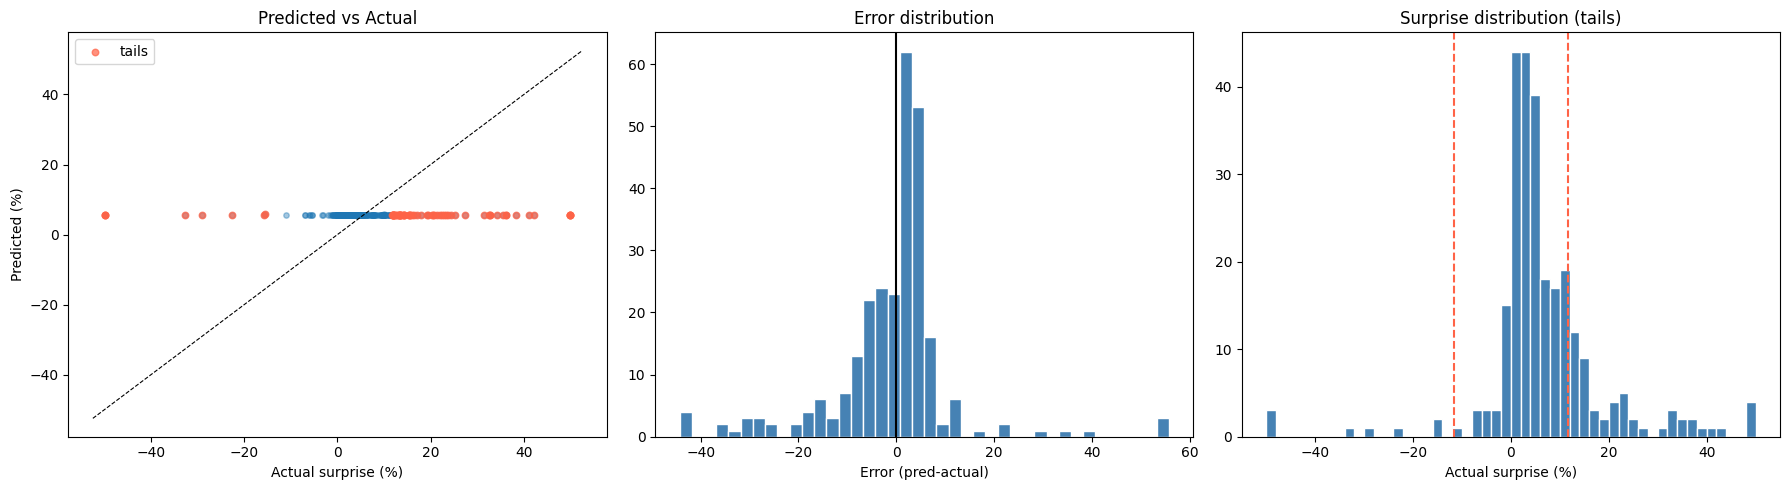

In [ ]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].scatter(st, sp, alpha=0.4, s=15); ax[0].scatter(st[tail], sp[tail], alpha=0.7, s=22, color="tomato", label="tails")
lim = max(abs(st).max(), abs(sp).max())*1.05; ax[0].plot([-lim,lim],[-lim,lim],"k--",lw=0.8)
ax[0].set(xlabel="Actual surprise (%)", ylabel="Predicted (%)", title="Predicted vs Actual"); ax[0].legend()
ax[1].hist(sp-st, bins=40, color="steelblue", edgecolor="white"); ax[1].axvline(0,color="k"); ax[1].set(xlabel="Error (pred-actual)", title="Error distribution")
ax[2].hist(st, bins=50, color="steelblue", edgecolor="white"); thr=np.percentile(np.abs(st),75)
ax[2].axvline(thr,color="tomato",ls="--"); ax[2].axvline(-thr,color="tomato",ls="--"); ax[2].set(xlabel="Actual surprise (%)", title="Surprise distribution (tails)")
plt.tight_layout(); plt.savefig("/content/eval.png", dpi=150, bbox_inches="tight"); plt.show()

#Testing to see if knowing the analysts or not affects the results of the model

In [ ]:
from scipy.stats import wilcoxon
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ablation device: {device}\n")

#Shared hyperparams (mirroring existing trained model)
HPARAMS = dict(
    n_analysts  = n_analysts,
    d_emb       = 16,
    d_cont      = 4,
    d_model     = 64,
    n_heads     = 4,
    n_layers    = 2,
    d_ff        = 128,
    max_len     = 51,
    dropout     = 0.1,
)
TRAIN_KWARGS = dict(
    n_epochs      = 50,
    lr            = 1e-4,
    weight_decay  = 1e-2,
    lambda_return = 0.5,
    patience      = 10,
    device        = device,
)


#Helper: collect per-sample squared errors
@torch.no_grad()
def per_sample_errors(model, loader):
    """Returns (preds, targets, squared_errors) as numpy arrays."""
    model.eval()
    preds_all, targets_all = [], []
    for batch in loader:
        cont = batch["cont_features"].to(device)
        aids = batch["analyst_ids"].to(device)
        mask = batch["pad_mask"].to(device)
        surp = batch["surprise"].numpy()
        surp_pred, _ = model(cont, aids, mask)
        preds_all.append(surp_pred.cpu().numpy())
        targets_all.append(surp)
    preds   = np.concatenate(preds_all)
    targets = np.concatenate(targets_all)
    return preds, targets, (preds - targets) ** 2


#Train WITH analyst embeddings
print("=" * 60)
print("Training  [WITH analyst identity embeddings]")
print("=" * 60)
torch.manual_seed(SEED)
model_with = EarningsTransformer(**HPARAMS, use_analyst_emb=True)
n_params_with = sum(p.numel() for p in model_with.parameters() if p.requires_grad)
print(f"  Parameters: {n_params_with:,}")
model_with = train(model_with, train_loader, val_loader, **TRAIN_KWARGS)
metrics_with = evaluate(model_with, test_loader, device)
_, _, se_with = per_sample_errors(model_with, test_loader)
rmse_with = float(np.sqrt(metrics_with["mse"]))
print(f"\n  Test → MSE={metrics_with['mse']:.4f}  "
      f"RMSE={rmse_with:.4f}  "
      f"MAE={metrics_with['mae']:.4f}  "
      f"DirAcc={metrics_with['dir_acc']:.4f}\n")


#Train WITHOUT analyst embeddings
print("=" * 60)
print("Training  [WITHOUT analyst identity embeddings]")
print("=" * 60)
torch.manual_seed(SEED)
model_without = EarningsTransformer(**HPARAMS, use_analyst_emb=False)
n_params_without = sum(p.numel() for p in model_without.parameters() if p.requires_grad)
print(f"  Parameters: {n_params_without:,}  "
      f"(embedding table removed: {n_params_with - n_params_without:,} params)")
model_without = train(model_without, train_loader, val_loader, **TRAIN_KWARGS)
metrics_without = evaluate(model_without, test_loader, device)
_, _, se_without = per_sample_errors(model_without, test_loader)
rmse_without = float(np.sqrt(metrics_without["mse"]))
print(f"\n  Test → MSE={metrics_without['mse']:.4f}  "
      f"RMSE={rmse_without:.4f}  "
      f"MAE={metrics_without['mae']:.4f}  "
      f"DirAcc={metrics_without['dir_acc']:.4f}\n")


'''Statistical test: paired Wilcoxon on squared errors
H0: embedding adds no benefit (median SE difference = 0)
H1 ("greater"): SE without embedding > SE with embedding
Wilcoxon preferred over t-test: surprise distribution is heavy-tailed.
 '''
stat, pval = wilcoxon(se_without, se_with, alternative="greater")


#Summary table
ablation_df = pd.DataFrame([
    {
        "Model":     "Transformer + analyst ID",
        "Params":    f"{n_params_with:,}",
        "Test MSE":  round(metrics_with["mse"],    4),
        "Test RMSE": round(rmse_with,              4),
        "Test MAE":  round(metrics_with["mae"],    4),
        "Dir Acc":   round(metrics_with["dir_acc"],4),
        "ΔRMSE":     "—",
    },
    {
        "Model":     "Transformer — analyst ID",
        "Params":    f"{n_params_without:,}",
        "Test MSE":  round(metrics_without["mse"],    4),
        "Test RMSE": round(rmse_without,              4),
        "Test MAE":  round(metrics_without["mae"],    4),
        "Dir Acc":   round(metrics_without["dir_acc"],4),
        "ΔRMSE":     f"+{rmse_without - rmse_with:.4f}",
    },
])
ablation_df = ablation_df.set_index("Model")

print("=" * 60)
print("EMBEDDING ABLATION — TEST SET RESULTS")
print("=" * 60)
display(ablation_df)

mse_delta  = metrics_without["mse"] - metrics_with["mse"]
rmse_delta = rmse_without - rmse_with
print(f"\nWilcoxon signed-rank (SE_without > SE_with): "
      f"stat={stat:.1f}, p={pval:.4f}")
if pval < 0.05:
    print(f"  → Analyst embeddings significantly help  "
          f"(MSE {metrics_with['mse']:.4f} vs {metrics_without['mse']:.4f}, Δ={mse_delta:+.4f} | "
          f"RMSE {rmse_with:.4f} vs {rmse_without:.4f}, Δ={rmse_delta:+.4f} | p<0.05).")
elif pval < 0.10:
    print(f"  → Marginal evidence that embeddings help  "
          f"(MSE Δ={mse_delta:+.4f} | RMSE Δ={rmse_delta:+.4f} | p<0.10).")
else:
    print(f"  → No significant benefit from analyst embeddings  "
          f"(MSE {metrics_with['mse']:.4f} vs {metrics_without['mse']:.4f}, Δ={mse_delta:+.4f} | "
          f"RMSE {rmse_with:.4f} vs {rmse_without:.4f}, Δ={rmse_delta:+.4f} | "
          f"p={pval:.3f}).")

#Save both models so that they can be used without running entire notebook/cell
torch.save(model_with.state_dict(),    "/content/model_with_emb.pt")
torch.save(model_without.state_dict(), "/content/model_no_emb.pt")
print("\nSaved: /content/model_with_emb.pt  |  /content/model_no_emb.pt")

Ablation device: cuda

Training  [WITH analyst identity embeddings]
  Parameters: 76,690
Epoch 001 | train_loss=10.1330 | val_mse=260.8682 | val_mae=10.4269 | val_dir_acc=0.6130
Epoch 002 | train_loss=10.2950 | val_mse=260.1466 | val_mae=10.3886 | val_dir_acc=0.7586
Epoch 003 | train_loss=10.0914 | val_mse=259.4137 | val_mae=10.3502 | val_dir_acc=0.8544
Epoch 004 | train_loss=10.0298 | val_mse=258.6565 | val_mae=10.3107 | val_dir_acc=0.8736
Epoch 005 | train_loss=10.0870 | val_mse=257.8705 | val_mae=10.2702 | val_dir_acc=0.8697
Epoch 006 | train_loss=10.2667 | val_mse=257.0359 | val_mae=10.2275 | val_dir_acc=0.8697
Epoch 007 | train_loss=9.9796 | val_mse=256.1531 | val_mae=10.1826 | val_dir_acc=0.8697
Epoch 008 | train_loss=10.0303 | val_mse=255.2209 | val_mae=10.1351 | val_dir_acc=0.8697
Epoch 009 | train_loss=10.6871 | val_mse=254.2351 | val_mae=10.0841 | val_dir_acc=0.8697
Epoch 010 | train_loss=9.9183 | val_mse=253.1704 | val_mae=10.0299 | val_dir_acc=0.8697
Epoch 011 | train_loss=

,Params,Test MSE,Test RMSE,Test MAE,Dir Acc,ΔRMSE
Model,,,,,,
Transformer + analyst ID,"76,690",154.4641,12.4284,7.5462,0.8764,—
Transformer — analyst ID,"71,682",155.4830,12.4693,7.4965,0.8764,+0.0409



Wilcoxon signed-rank (SE_without > SE_with): stat=17879.0, p=0.5032
  → No significant benefit from analyst embeddings  (MSE 154.4641 vs 155.4830, Δ=+1.0189 | RMSE 12.4284 vs 12.4693, Δ=+0.0409 | p=0.503).

Saved: /content/model_with_emb.pt  |  /content/model_no_emb.pt


In [ ]:
from scipy.stats import pearsonr

# LSTM IC (uses the same collect() you already defined)
sp_lstm, st_lstm, *_ = collect(trained_lstm.to(device).eval(), test_loader)
print("LSTM IC:", round(pearsonr(sp_lstm, st_lstm)[0], 3))

# Ridge full metrics, from the SAME run that gave IC 0.019 / RMSE 13.6
# (pred_ridge and true_ridge exist in your ic_report cell)
print("Ridge:", {k: round(v, 4) for k, v in metrics(pred_ridge, true_ridge).items()})


LSTM IC: 0.038
Ridge: {'RMSE': np.float64(13.5952), 'MAE': np.float64(8.5501), 'DirAcc': np.float64(0.8727), 'BalAcc': np.float64(0.4979), 'IC(r)': np.float64(0.0193)}
